Import statements

In [40]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA")

2.7.0+cu128
True
NVIDIA GeForce RTX 4070


In [41]:
import math
from collections import OrderedDict

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2

import numpy as np
from numpy import allclose, isclose

from collections.abc import Callable

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

from PIL import Image
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

from torch.utils.data import random_split

# TH

cuda


In [ ]:
import os, random, glob
from PIL import Image
from torchvision import transforms

def augment_and_save(source_dir, target_dir, target_count=100):
    spatial_aug = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    ])
    colour_aug = transforms.Compose([
        transforms.RandomPosterize(bits=4, p=0.3),
        transforms.RandomSolarize(threshold=200, p=0.2),
    ])

    # AI helped me with this.
    classes = [d for d in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, d))]
    # END AI
    

    for classname in classes:

        # AI helped me with this.
        class_src = os.path.join(source_dir, classname)
        class_dst = os.path.join(target_dir, classname)
        os.makedirs(class_dst, exist_ok=True)
        images = [f for f in os.listdir(class_src) if f.endswith('.png')]

        # END AI

        if not images:
            continue

        # AI helped me with this.
        for img_file in images:
            img = Image.open(os.path.join(class_src, img_file)).convert('RGBA')
            img.save(os.path.join(class_dst, img_file))
        count = len(images)
        i = 0
        # END AI

        while count < target_count:
            src_path = os.path.join(class_src, images[i % len(images)])
            src_img = Image.open(src_path).convert('RGBA')
            
            aug_rgba = spatial_aug(src_img)

            r, g, b, a = aug_rgba.split()
            rgb = Image.merge('RGB', (r, g, b))
            rgb = colour_aug(rgb)
            aug_rgba = rgb.convert('RGBA')
            aug_rgba.putalpha(a)  

            aug_rgba.save(os.path.join(class_dst, f'aug_{count}.png'))
            count += 1
            i += 1
        print(f'{classname:10s}: {len(images)} orig -> {count} total')

import shutil
if os.path.exists('data/assets_augmented/'):
    shutil.rmtree('data/assets_augmented/')
    print('Cleared old assets_augmented/')
augment_and_save('data/assets/', 'data/assets_augmented/', target_count=100)

Cleared old assets_augmented/
boots     : 22 orig -> 100 total
box       : 19 orig -> 100 total
coin      : 25 orig -> 100 total
exit      : 22 orig -> 100 total
floor     : 25 orig -> 100 total
gem       : 25 orig -> 100 total
ghost     : 25 orig -> 100 total
human     : 32 orig -> 100 total
key       : 22 orig -> 100 total
lava      : 25 orig -> 100 total
locked    : 22 orig -> 100 total
opened    : 25 orig -> 100 total
shield    : 19 orig -> 100 total
wall      : 25 orig -> 100 total
Done! Now run the dataloader cell and then train.


In [ ]:
import os, random
import glob
from torch.utils.data import Subset

# FROM problemset 4
train_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])
# END FROM problemset 4

_floor_paths = sorted(glob.glob('data/assets/floor/floor_*.png'))
_floor_tiles = [
    Image.open(p).convert('RGBA').resize((28, 28))
    for p in _floor_paths
]
print(f'Loaded {len(_floor_tiles)} floor tiles for background augmentation')

train_dataset = ImageFolder(
    DATA_DIR,
    transform=train_transform,
    loader=load_rgba_on_random_floor
)
val_dataset = ImageFolder(
    DATA_DIR,
    transform=val_transform,
    loader=load_rgba_on_floor1
)


train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
indices = list(range(len(train_dataset)))
random.shuffle(indices)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_set = Subset(train_dataset, train_indices)
val_set   = Subset(val_dataset,   val_indices)

train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=16, shuffle=False)

print(f'Total images: {len(train_dataset)}')
print(f'Training images: {len(train_set)}')
print(f'Validation images: {len(val_set)}')

Loaded 25 floor tiles for background augmentation
Total images: 1400
Training images: 1120
Validation images: 280


CNN model

In [ ]:

# FROM problemset 4
class CNNmodel(nn.Module):
    def __init__(self, classes=14):
        super().__init__()
        self.conv = nn.Sequential(
            # Block 1
            nn.Conv2d(4, 32, (3,3)),
            nn.MaxPool2d(2, 2),
            nn.LeakyReLU(0.1),
            # Block 2
            nn.Conv2d(32, 64, (3,3)),
            nn.MaxPool2d(2, 2),
            nn.LeakyReLU(0.1),
            # Block 3 
            nn.Conv2d(64, 128, (3,3)),
            nn.MaxPool2d(2, 2),
            nn.LeakyReLU(0.1),
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),
            nn.Linear(128, classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        x = x.mean(dim=[2, 3])  # pooling 
        x = self.fc(x)
        return x
    # END PS4

model = CNNmodel(classes=14)
print(model)

# Quick test
imgs, labels = next(iter(train_loader))
print(f'Input shape: {imgs.shape}')   # should be [32, 4, 64, 64]
out = model(imgs)
print(f'Output shape: {out.shape}')   # should be [32, 14]


CNNmodel(
  (conv): Sequential(
    (0): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): LeakyReLU(negative_slope=0.1)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): LeakyReLU(negative_slope=0.1)
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.1)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=14, bias=True)
  )
)
Input shape: torch.Size([16, 4, 28, 28])
Output sha

train

In [ ]:

# MOST FROM problemset 4
def train_model(model: nn.Module, dataloader: DataLoader, epochs: int = 20):
    losses = []
    optimiser = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=10, factor=0.5)

    model.train()
    for i in range(epochs):
        epoch_loss = 0.0
        samples_seen = 0
        for x_batch, y_batch in dataloader:
            """ YOUR CODE HERE """
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimiser.zero_grad()
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            # Reference https://stackoverflow.com/questions/54716377/how-to-do-gradient-clipping-in-pytorch
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            """ YOUR CODE END HERE """
            epoch_loss += loss.item() * x_batch.shape[0]
            samples_seen += x_batch.shape[0]
        epoch_loss /= len(dataloader.dataset)
        scheduler.step(epoch_loss) 
        print(f'Epoch {i+1}/{epochs}, Loss: {epoch_loss:.4f}')
        losses.append(epoch_loss)

    return model, losses

trained_model, losses = train_model(CNNmodel(classes=14).to(device), train_loader, epochs=160)


Epoch 1/160, Loss: 2.3208
Epoch 2/160, Loss: 1.4966
Epoch 3/160, Loss: 1.2838
Epoch 4/160, Loss: 1.1818
Epoch 5/160, Loss: 1.0020
Epoch 6/160, Loss: 0.8558
Epoch 7/160, Loss: 0.7768
Epoch 8/160, Loss: 0.6733
Epoch 9/160, Loss: 0.5672
Epoch 10/160, Loss: 0.4947
Epoch 11/160, Loss: 0.4998
Epoch 12/160, Loss: 0.4122
Epoch 13/160, Loss: 0.3986
Epoch 14/160, Loss: 0.4169
Epoch 15/160, Loss: 0.3693
Epoch 16/160, Loss: 0.3384
Epoch 17/160, Loss: 0.3404
Epoch 18/160, Loss: 0.3123
Epoch 19/160, Loss: 0.2839
Epoch 20/160, Loss: 0.3160
Epoch 21/160, Loss: 0.2646
Epoch 22/160, Loss: 0.2270
Epoch 23/160, Loss: 0.2728
Epoch 24/160, Loss: 0.3045
Epoch 25/160, Loss: 0.2347
Epoch 26/160, Loss: 0.1943
Epoch 27/160, Loss: 0.2756
Epoch 28/160, Loss: 0.2788
Epoch 29/160, Loss: 0.2305
Epoch 30/160, Loss: 0.1824
Epoch 31/160, Loss: 0.2194
Epoch 32/160, Loss: 0.1984
Epoch 33/160, Loss: 0.1587
Epoch 34/160, Loss: 0.1833
Epoch 35/160, Loss: 0.1927
Epoch 36/160, Loss: 0.2068
Epoch 37/160, Loss: 0.1293
Epoch 38/1

Test

In [ ]:
class_correct = [0] * 14
class_total = [0] * 14
confusion = {}  

with torch.no_grad():
    trained_model.eval()
    for x_batch, y_batch in val_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = trained_model(x_batch)
        predicted = outputs.argmax(dim=1)
        for label, pred in zip(y_batch, predicted):
            label, pred = label.item(), pred.item()
            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1
            else:
                true_name = train_dataset.classes[label]
                pred_name = train_dataset.classes[pred]
                if true_name not in confusion:
                    confusion[true_name] = {}
                confusion[true_name][pred_name] = confusion[true_name].get(pred_name, 0) + 1

print("=" * 40)
print(f"{'Class':10s}  {'Acc':>6}  Wrong predictions")
print("=" * 40)
for i, classname in enumerate(train_dataset.classes):
    if class_total[i] > 0:
        acc = 100 * class_correct[i] / class_total[i]
        wrong = confusion.get(classname, {})
        wrong_str = ", ".join([f"{k}({v})" for k, v in wrong.items()]) if wrong else "none"
        print(f"{classname:10s}  {acc:>5.1f}%  {wrong_str}")

Class          Acc  Wrong predictions
boots       100.0%  none
box         100.0%  none
coin        100.0%  none
exit         94.7%  locked(1)
floor       100.0%  none
gem          95.0%  shield(1)
ghost       100.0%  none
human       100.0%  none
key         100.0%  none
lava        100.0%  none
locked      100.0%  none
opened      100.0%  none
shield      100.0%  none
wall        100.0%  none


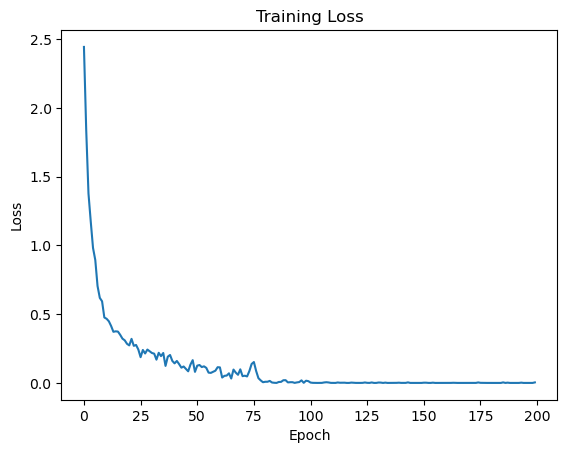

In [ ]:
import matplotlib.pyplot as plt

# FROM ps4
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [6]:
import os
for classname in train_dataset.classes:
    path = f'data/assets/{classname}'
    count = len(os.listdir(path))
    print(f"{classname:10s}: {count} images")

boots     : 22 images
box       : 19 images
coin      : 25 images
exit      : 22 images
floor     : 25 images
gem       : 25 images
ghost     : 25 images
human     : 32 images
key       : 22 images
lava      : 25 images
locked    : 22 images
opened    : 25 images
shield    : 19 images
wall      : 25 images


In [ ]:
import os, random, glob
from PIL import Image
from torchvision import transforms

def augment_and_save(source_dir, target_dir, target_count=100):
    """
    Run this ONCE before training to create a balanced dataset.
    Saves RGBA sprites (no background) — the dataloader composites
    onto random floor tiles on-the-fly during training.
    """
    augmentations = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(360),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.RandomPosterize(bits=4, p=0.3),
        transforms.RandomSolarize(threshold=200, p=0.2),
    ])

    classes = [d for d in os.listdir(source_dir)
               if os.path.isdir(os.path.join(source_dir, d))]

    for classname in classes:
        class_src = os.path.join(source_dir, classname)
        class_dst = os.path.join(target_dir, classname)
        os.makedirs(class_dst, exist_ok=True)

        images = [f for f in os.listdir(class_src) if f.endswith('.png')]
        if not images:
            continue

      
        for img_file in images:
            img = Image.open(os.path.join(class_src, img_file)).convert('RGBA')
            img.save(os.path.join(class_dst, img_file))


        count = len(images)
        i = 0
        while count < target_count:
            src_path = os.path.join(class_src, images[i % len(images)])
            src_img = Image.open(src_path).convert('RGBA')
            rgb = src_img.convert('RGB')
            alpha = src_img.split()[3]          # preserve original alpha mask
            aug_rgb = augmentations(rgb)
            aug_rgba = aug_rgb.convert('RGBA')
            aug_rgba.putalpha(alpha)             # reattach alpha
            aug_rgba.save(os.path.join(class_dst, f'aug_{count}.png'))
            count += 1
            i += 1

        print(f'{classname:10s}: {len(images)} orig -> {count} total')

# !!!!!!!!!!!! RUN THIS CELL FIRST, before the dataloader cell !!!!!!!!!!!!!!!!!!!!!!!!!!!!!
augment_and_save('data/assets/', 'data/assets_augmented/', target_count=100)
print('Done! Now run the dataloader cell (cell 2) and then train.')


boots     : 22 orig -> 100 total
box       : 19 orig -> 100 total
coin      : 25 orig -> 100 total
exit      : 22 orig -> 100 total
floor     : 25 orig -> 100 total
gem       : 25 orig -> 100 total
ghost     : 25 orig -> 100 total
human     : 32 orig -> 100 total
key       : 22 orig -> 100 total
lava      : 25 orig -> 100 total
locked    : 22 orig -> 100 total
opened    : 25 orig -> 100 total
shield    : 19 orig -> 100 total
wall      : 25 orig -> 100 total
Done! Now run the dataloader cell (cell 2) and then train.


In [53]:
from utils import generate_torch_loader_snippet

example_input = torch.tensor([[0.0, 0.0]], dtype=torch.float32)  # minimal example for tracing if needed
snippet = generate_torch_loader_snippet(trained_model, example_inputs=example_input, prefer="auto", compression="zlib")
print(snippet)

def get_model(device: str = "cpu", dtype: str | None = None):
    """
    Return a TorchScript model loaded from an embedded, base64-encoded compressed blob.
    Self-contained: no need for the original Python class.

    Args:
        device: Where to map the model (e.g., "cpu", "cuda", "cuda:0").
        dtype: Optional dtype to convert parameters/buffers to (e.g., "float32", "float16").
    """
    import base64, io, torch
    import zlib as _z; _decomp = _z.decompress
    _blob_b64 = "..."
    _raw = _decomp(base64.b64decode(_blob_b64))
    buf = io.BytesIO(_raw)
    m = torch.jit.load(buf, map_location=device)
    if dtype is not None:
        dt = getattr(torch, dtype) if isinstance(dtype, str) else dtype
        for p in m.parameters():
            p.data = p.data.to(dt)
        for b in m.buffers():
            b.data = b.data.to(dt)
    m.eval()
    return m

